In [1]:
"""
Data Scraping and Correlation Analysis

This section focuses on enriching the original wildfire structural damage dataset
by integrating additional environmental features using two external data sources:

1. Open-Meteo API:
   - Used to retrieve historical weather data, including temperature (°C),
     wind speed (km/h), and relative humidity (%).
   - Data was collected using latitude, longitude, and the fire incident start date
     for each structure.
   - The API responses were parsed using Python's `requests` library and added as
     new columns: `temp_c`, `humidity`, and `wind_kph`.

2. Google Earth Engine (MODIS NDVI):
   - MODIS MOD13Q1 dataset was used to obtain NDVI (Normalized Difference Vegetation Index)
     values for vegetation coverage around each structure.
   - NDVI was extracted using a ±16-day window around the incident start date,
     filtered spatially using each structure’s coordinates.
   - The resulting NDVI values were added to the dataset as a new column: `NDVI`.

After scraping, all new features were cleaned and merged with the original dataset.
A correlation matrix was computed and visualized to explore the relationships between
the new features (NDVI, temperature, humidity, wind speed, utility distance) and to
understand their potential influence on the target damage variable.

This step added critical real-world context to the data and laid the foundation
for more accurate and interpretable machine learning models.
"""


"\nData Scraping and Correlation Analysis\n\nThis section focuses on enriching the original wildfire structural damage dataset\nby integrating additional environmental features using two external data sources:\n\n1. Open-Meteo API:\n   - Used to retrieve historical weather data, including temperature (°C),\n     wind speed (km/h), and relative humidity (%).\n   - Data was collected using latitude, longitude, and the fire incident start date\n     for each structure.\n   - The API responses were parsed using Python's `requests` library and added as\n     new columns: `temp_c`, `humidity`, and `wind_kph`.\n\n2. Google Earth Engine (MODIS NDVI):\n   - MODIS MOD13Q1 dataset was used to obtain NDVI (Normalized Difference Vegetation Index)\n     values for vegetation coverage around each structure.\n   - NDVI was extracted using a ±16-day window around the incident start date,\n     filtered spatially using each structure’s coordinates.\n   - The resulting NDVI values were added to the datas

In [1]:
pip install requests tqdm


In [3]:
import pandas as pd
import requests
from tqdm import tqdm
from datetime import datetime

# Load your full dataset
df = pd.read_csv("Wildfire_Capstone_Updated.csv")

# Drop rows with missing essentials
df = df.dropna(subset=["Latitude", "Longitude", "Incident Start Date"])
df["Incident Start Date"] = pd.to_datetime(df["Incident Start Date"], errors="coerce")
df = df.dropna(subset=["Incident Start Date"])

# Round coordinates for grouping (0.01 ~ 1km accuracy)
df["lat_rounded"] = df["Latitude"].round(2)
df["lon_rounded"] = df["Longitude"].round(2)
df["date_str"] = df["Incident Start Date"].dt.strftime("%Y-%m-%d")

# Unique (lat, lon, date) combinations
unique_locations = df[["lat_rounded", "lon_rounded", "date_str"]].drop_duplicates()

# Cache dictionary for storing fetched weather data
weather_cache = {}

# Query Open-Meteo API for each unique group
for _, row in tqdm(unique_locations.iterrows(), total=len(unique_locations)):
    lat = row["lat_rounded"]
    lon = row["lon_rounded"]
    date = row["date_str"]
    key = (lat, lon, date)

    try:
        response = requests.get(
            "https://archive-api.open-meteo.com/v1/archive",
            params={
                "latitude": lat,
                "longitude": lon,
                "start_date": date,
                "end_date": date,
                "hourly": "temperature_2m,relative_humidity_2m,windspeed_10m",
                "timezone": "auto"
            },
            timeout=10
        )
        data = response.json()
        if "hourly" in data:
            temp = sum(data["hourly"]["temperature_2m"]) / len(data["hourly"]["temperature_2m"])
            humidity = sum(data["hourly"]["relative_humidity_2m"]) / len(data["hourly"]["relative_humidity_2m"])
            wind = sum(data["hourly"]["windspeed_10m"]) / len(data["hourly"]["windspeed_10m"])
            weather_cache[key] = (temp, humidity, wind)
        else:
            weather_cache[key] = (None, None, None)

    except Exception as e:
        print(f"Failed to get data for {key}: {e}")
        weather_cache[key] = (None, None, None)

# Map back to original dataset
def fetch_weather(row):
    key = (row["lat_rounded"], row["lon_rounded"], row["date_str"])
    return weather_cache.get(key, (None, None, None))

df[["temp_c", "humidity", "wind_kph"]] = df.apply(fetch_weather, axis=1, result_type="expand")

# Drop helper columns
df.drop(columns=["lat_rounded", "lon_rounded", "date_str"], inplace=True)

# Save output
df.to_csv("Wildfire_Updated_With_Weather.csv", index=False)


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_30048\4288027379.py:7: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Capstone_Updated.csv")
 34%|█████████████████████████▌                                                  | 2341/6965 [17:15<4:23:23,  3.42s/it]

Failed to get data for (33.93, -117.68, '2020-10-26'): HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


 34%|█████████████████████████▌                                                  | 2342/6965 [17:25<7:02:59,  5.49s/it]

Failed to get data for (33.93, -117.67, '2020-10-26'): HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


 85%|████████████████████████████████████████████████████████████████▍           | 5902/6965 [44:05<1:12:14,  4.08s/it]

...

 85%|████████████████████████████████████████████████████████████████▍           | 5905/6965 [44:36<2:24:36,  8.19s/it]

Failed to get data for (34.48, -120.04, '2021-10-11'): HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


 85%|████████████████████████████████████████████████████████████████▍           | 5906/6965 [44:46<2:35:47,  8.83s/it]

Failed to get data for (34.46, -120.05, '2021-10-11'): HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


100%|██████████████████████████████████████████████████████████████████████████████| 6965/6965 [52:28<00:00,  2.21it/s]


In [7]:
import ee
import pandas as pd
from tqdm import tqdm

# Initialize Earth Engine
ee.Initialize()

# Load weather-enriched dataset
df = pd.read_csv("Wildfire_Updated_With_Weather.csv")
df["Incident Start Date"] = pd.to_datetime(df["Incident Start Date"], errors="coerce")

# Round coordinates and build group key
df["lat_r"] = df["Latitude"].round(4)
df["lon_r"] = df["Longitude"].round(4)
df["date_str"] = df["Incident Start Date"].dt.strftime("%Y-%m-%d")

# Get unique query points
unique_keys = df[["lat_r", "lon_r", "Incident Start Date"]].drop_duplicates()
ndvi_cache = {}

# Loop over unique (lat, lon, date) keys
for _, row in tqdm(unique_keys.iterrows(), total=len(unique_keys)):
    lat = row["lat_r"]
    lon = row["lon_r"]
    date = row["Incident Start Date"]
    key = (lat, lon, date.strftime("%Y-%m-%d"))

    point = ee.Geometry.Point([lon, lat])
    start_date = ee.Date(date.strftime("%Y-%m-%d"))
    end_date = start_date.advance(16, 'day')  # MODIS 16-day cycle

    try:
        # Use MODIS NDVI
        collection = (
            ee.ImageCollection("MODIS/006/MOD13Q1")
            .filterBounds(point)
            .filterDate(start_date, end_date)
            .select("NDVI")
        )

        # Median NDVI from the 16-day cycle
        image = collection.median()
        ndvi_raw = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=250,
            maxPixels=1e9
        ).getInfo().get("NDVI", None)

        # MODIS NDVI is scaled by 10,000
        ndvi_value = ndvi_raw / 10000.0 if ndvi_raw is not None else None
        ndvi_cache[key] = ndvi_value

    except Exception as e:
        print(f"MODIS NDVI failed for {key}: {e}")
        ndvi_cache[key] = None

# Assign NDVI values back to original DataFrame
def get_ndvi(row):
    key = (round(row["Latitude"], 4), round(row["Longitude"], 4), row["Incident Start Date"].strftime("%Y-%m-%d"))
    return ndvi_cache.get(key, None)

df["NDVI"] = df.apply(get_ndvi, axis=1)

# Clean up
df.drop(columns=["lat_r", "lon_r", "date_str"], inplace=True)

# Save final file
df.to_csv("Wildfire_Final_With_Weather_MODIS_NDVI.csv", index=False)


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\3440944876.py:9: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Updated_With_Weather.csv")
  0%|                                                                                        | 0/98958 [00:00<?, ?it/s]D:\Coderboimolly\Lib\site-packages\ee\deprecation.py:207: DeprecationWarning: 

Attention required for MODIS/006/MOD13Q1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/MODIS_006_MOD13Q1

  warnings.warn(warning, category=DeprecationWarning)
 22%|████████████████                                                          | 21454/98958 [50:32<7:24:47,  2.90it/s]

MODIS NDVI failed for (37.0551, -122.1653, '2020-08-16'): Not signed up for Earth Engine or project is not registered. Visit https://developers.google.com/earth-engine/guides/access


100%|██████████████████████████████████████████████████████████████████████████| 98958/98958 [3:55:52<00:00,  6.99it/s]


In [9]:
import pandas as pd

# Load the dataset
df = pd.read_csv("Wildfire_Final_With_Weather_MODIS_NDVI.csv")

# Ensure values are numeric
cols = ['temp_c', 'humidity', 'wind_kph', 'NDVI']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Fill missing values with median
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

# Save the cleaned dataset
df.to_csv("Wildfire_Cleaned_With_Weather_NDVI.csv", index=False)


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2784365179.py:4: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Final_With_Weather_MODIS_NDVI.csv")
C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2784365179.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2407539756.py:6: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")


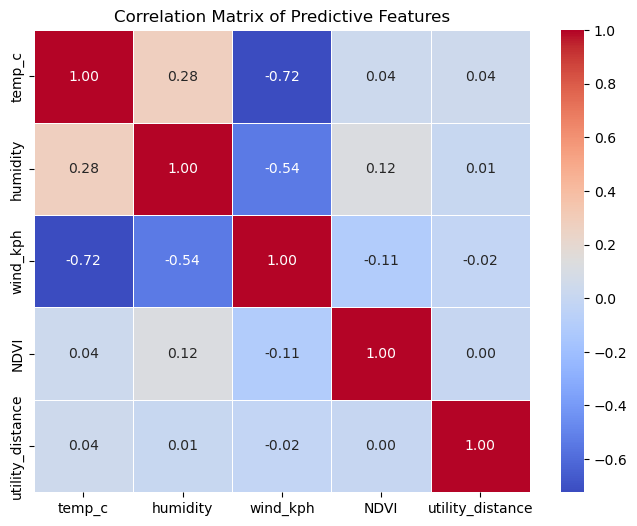

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")

# Ensure all required columns are numeric
cols = ['temp_c', 'humidity', 'wind_kph', 'NDVI', 'utility_distance']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values in selected columns (if any remain)
df = df.dropna(subset=cols)

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Predictive Features')
plt.show()


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:6: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")
C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')


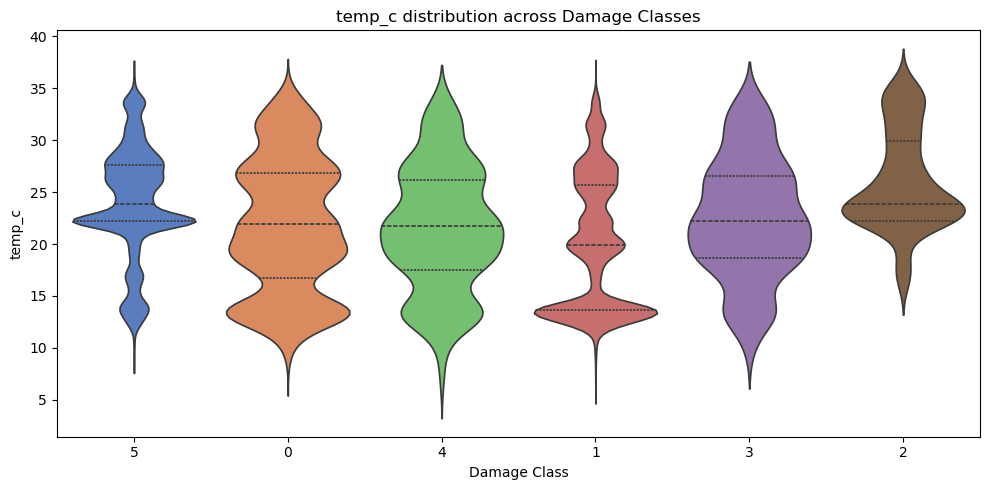

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')


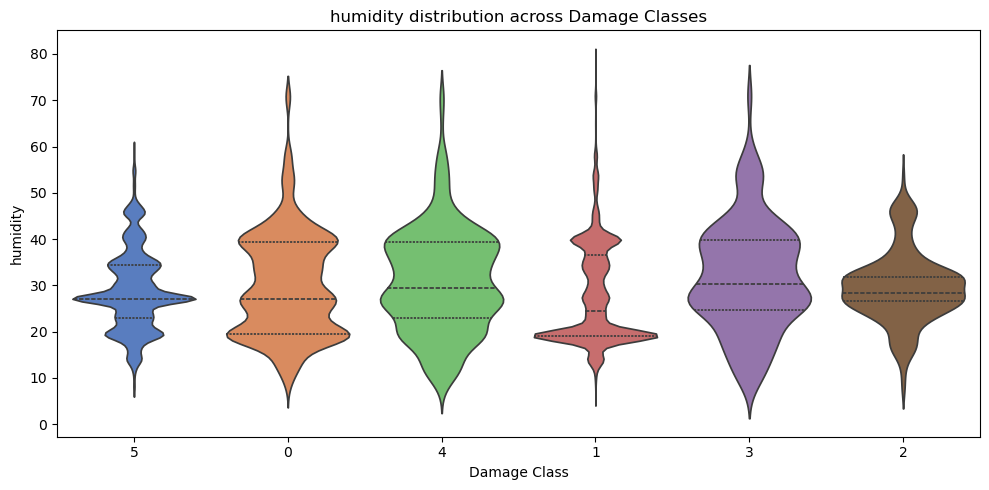

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')


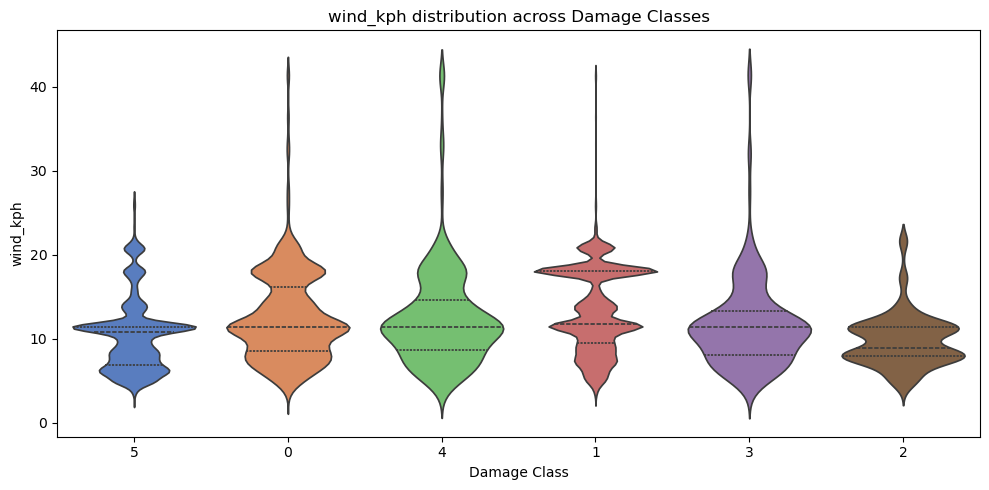

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')


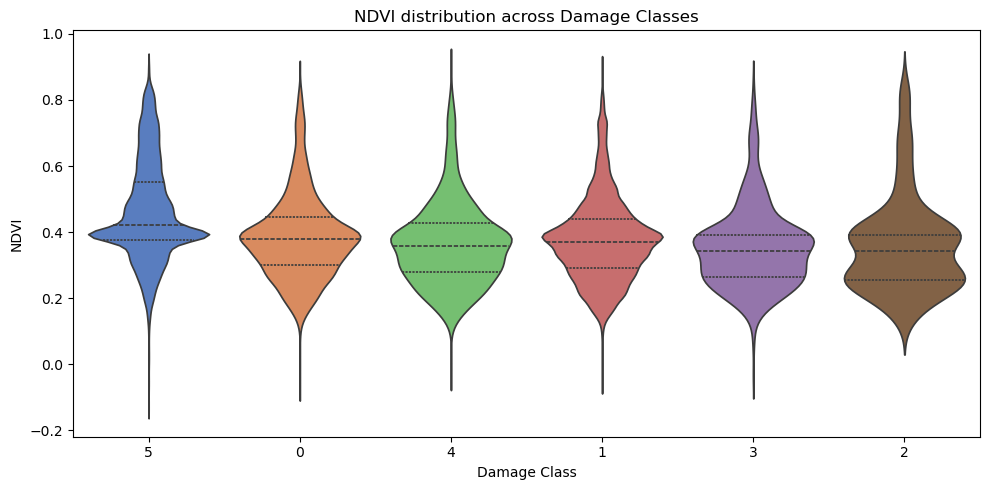

C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2091267311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')


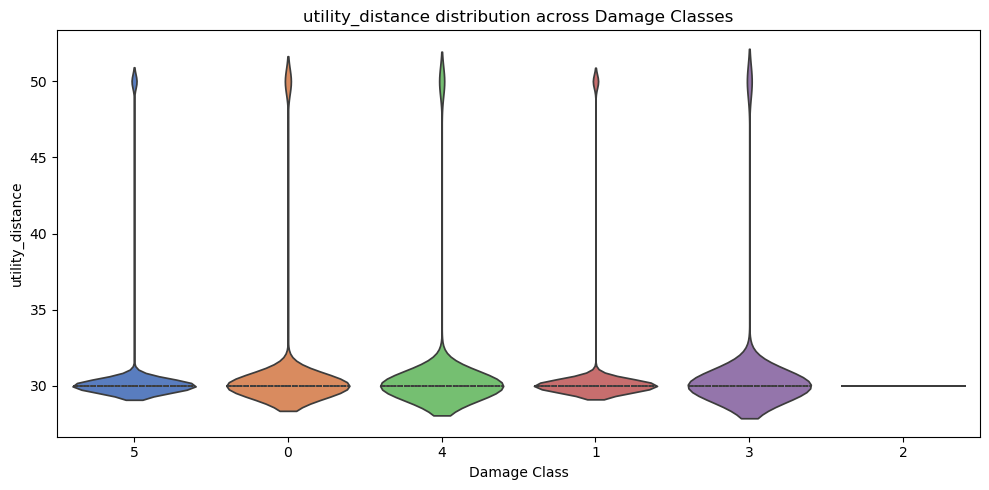

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")

# Rename target column for simplicity if needed
df.rename(columns={"* Damage": "damage_class"}, inplace=True)

# Drop rows with missing damage_class or convert to string for clarity
df = df.dropna(subset=["damage_class"])
df["damage_class"] = df["damage_class"].astype(str)

# List of features to plot
features = ['temp_c', 'humidity', 'wind_kph', 'NDVI', 'utility_distance']

# Plot each feature distribution across classes
for feature in features:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x='damage_class', y=feature, inner='quartile', palette='muted')
    plt.title(f"{feature} distribution across Damage Classes")
    plt.xlabel("Damage Class")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2328418519.py:7: DtypeWarning: Columns (14,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")
C:\Users\Mriganko Saha\AppData\Local\Temp\ipykernel_16116\2328418519.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=features, y=f_scores, palette='viridis')


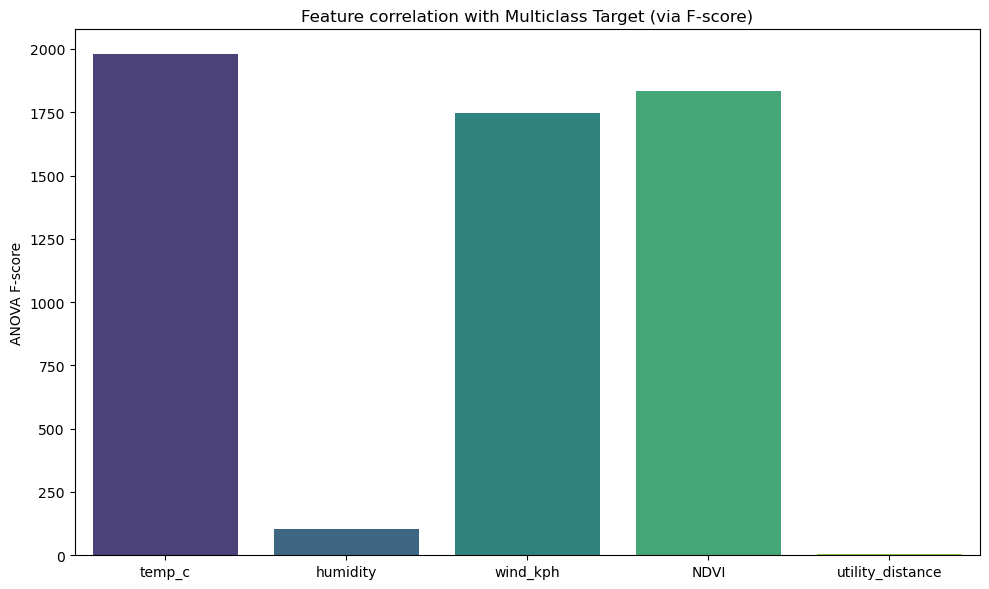

In [17]:
import pandas as pd
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Wildfire_Cleaned_With_Weather_NDVI.csv")
df.rename(columns={"* Damage": "damage_class"}, inplace=True)

# Drop NA
df = df.dropna(subset=['damage_class'])

# Encode target variable (if it's a string)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["damage_encoded"] = le.fit_transform(df["damage_class"])

# Select features and target
features = ['temp_c', 'humidity', 'wind_kph', 'NDVI', 'utility_distance']
X = df[features]
y = df["damage_encoded"]

# Compute ANOVA F-scores
f_scores, _ = f_classif(X, y)

